In [3]:
import pandas as pd

<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


Processing files and generating plots:   0%|          | 0/6 [00:00<?, ?it/s]

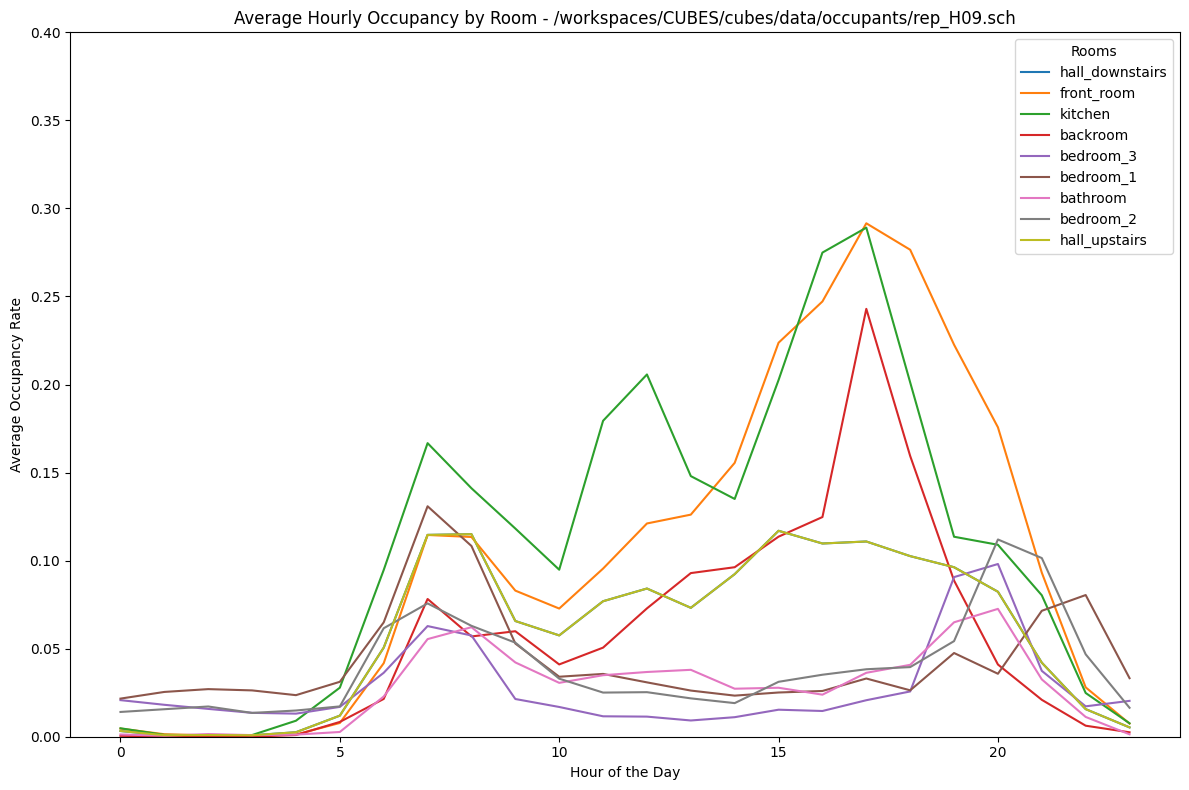

Processing files and generating plots:  17%|█▋        | 1/6 [00:04<00:23,  4.62s/it]

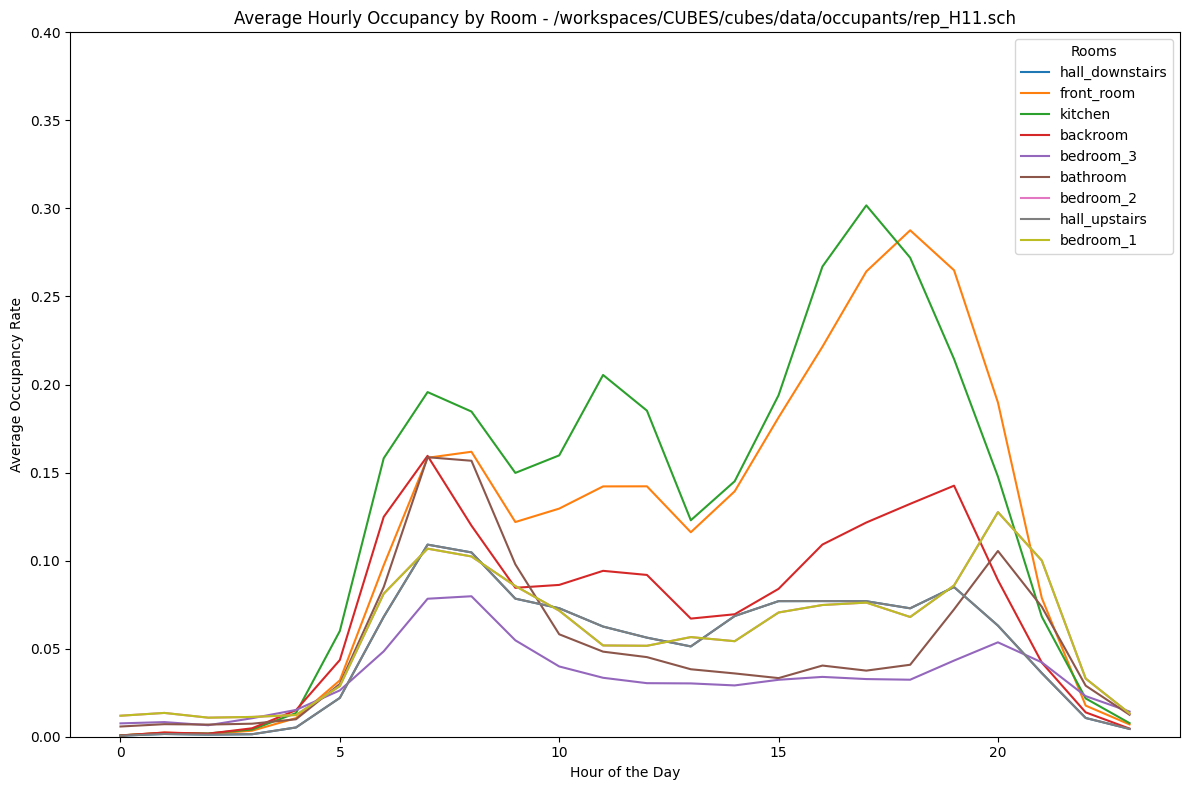

Processing files and generating plots:  33%|███▎      | 2/6 [00:08<00:17,  4.46s/it]

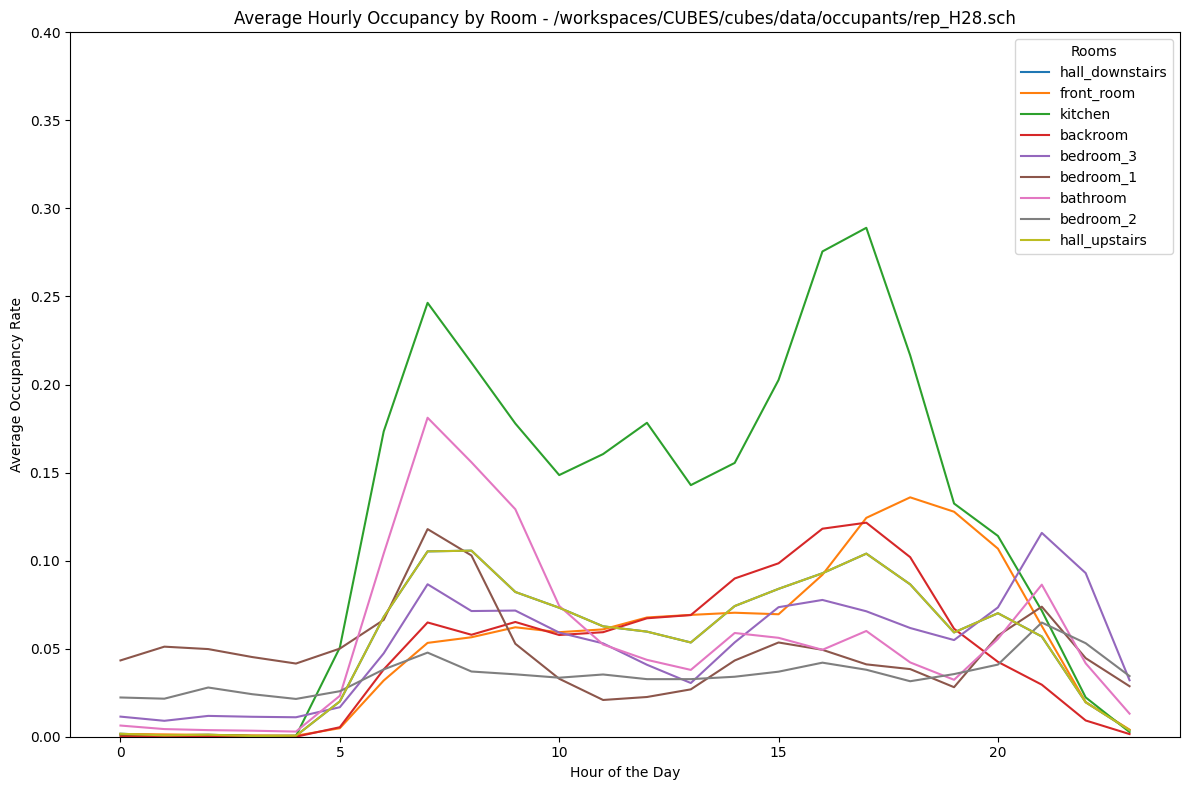

Processing files and generating plots:  50%|█████     | 3/6 [00:13<00:13,  4.35s/it]

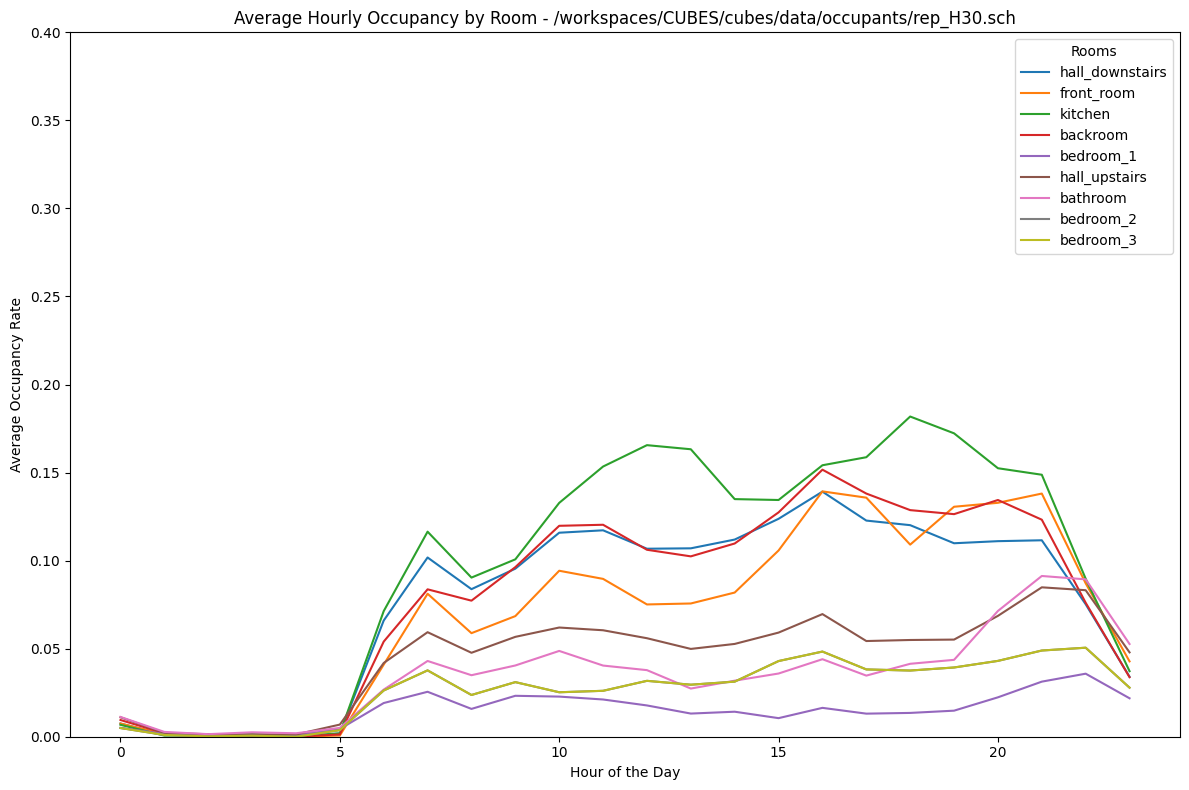

Processing files and generating plots:  67%|██████▋   | 4/6 [00:17<00:08,  4.34s/it]

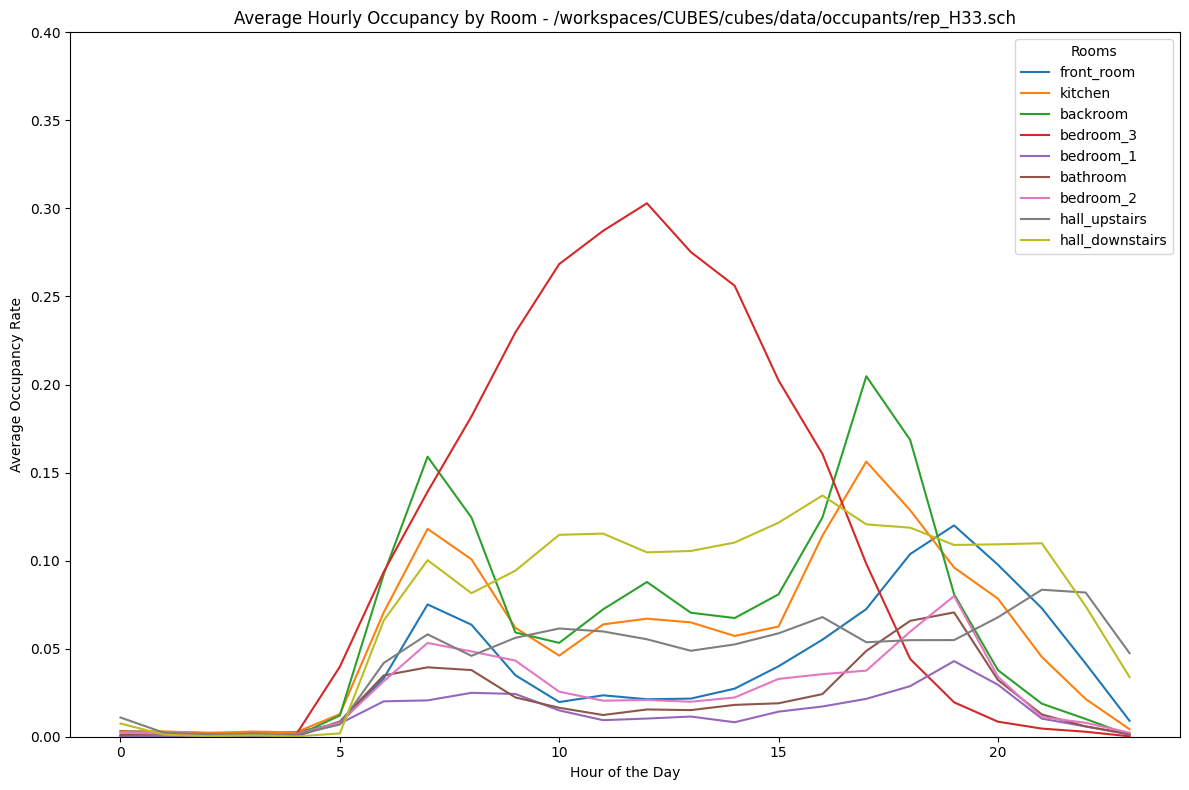

Processing files and generating plots:  83%|████████▎ | 5/6 [00:21<00:04,  4.39s/it]

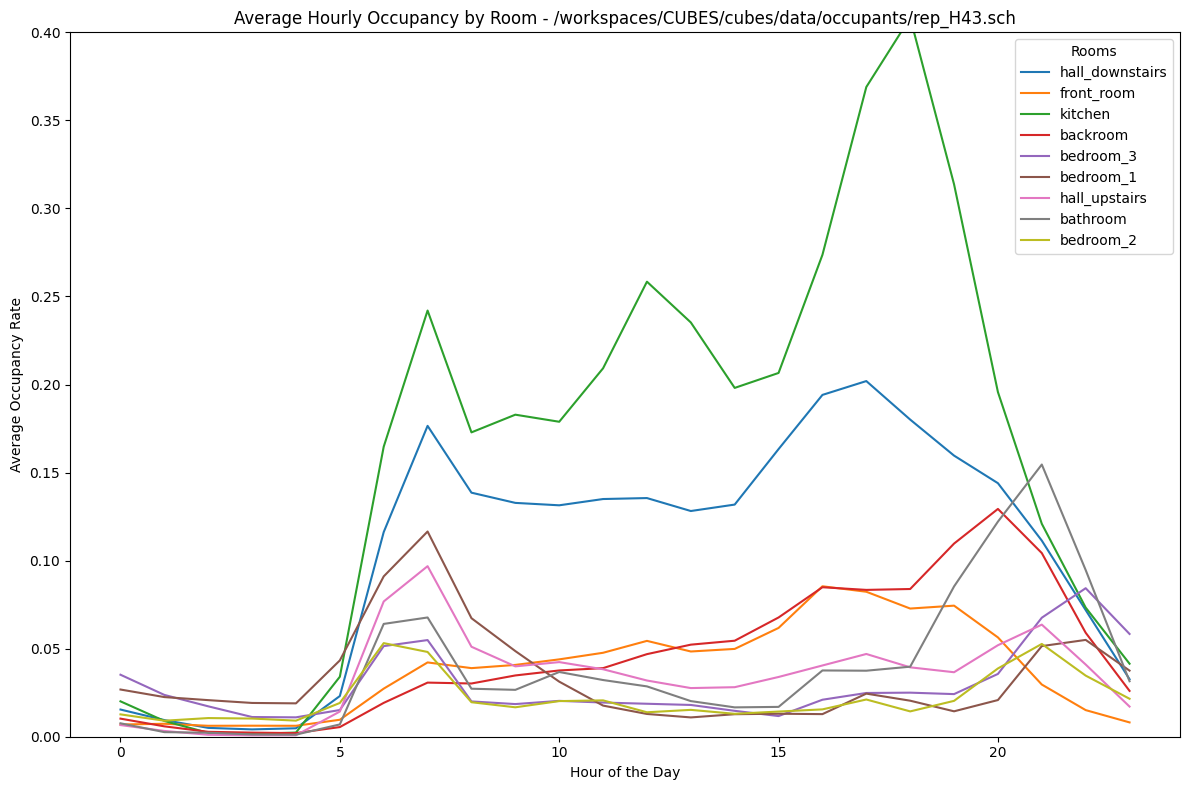

Processing files and generating plots: 100%|██████████| 6/6 [00:26<00:00,  4.42s/it]


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm  # Progress bar

# List of file paths
paths = [
    "/workspaces/CUBES/cubes/data/occupants/rep_H09.sch",
    "/workspaces/CUBES/cubes/data/occupants/rep_H11.sch",
    "/workspaces/CUBES/cubes/data/occupants/rep_H28.sch",
    "/workspaces/CUBES/cubes/data/occupants/rep_H30.sch",
    "/workspaces/CUBES/cubes/data/occupants/rep_H33.sch",
    "/workspaces/CUBES/cubes/data/occupants/rep_H43.sch",
]

# Function to calculate average occupancy by hour for each room
def calculate_average_occupancy_per_hour(path):
    try:
        # Load the data
        df = pd.read_csv(path)

        # Convert UTC_Time to datetime
        df['UTC_Time'] = pd.to_datetime(df['UTC_Time'])

        # Set UTC_Time as the index
        df.set_index('UTC_Time', inplace=True)

        # Apply the condition that occupancy is determined if the value is > 0 (convert to 1 for occupied, 0 for unoccupied)
        df = df.gt(0).astype(int)

        # Group by hour of the day and calculate the mean occupancy rate per room
        occupancy_per_hour = df.groupby(df.index.hour).mean()

        return occupancy_per_hour

    except Exception as e:
        print(f"Error processing file {path}: {e}")
        return None

# Function to plot the average hourly occupancy for each room for a specific path
def plot_average_occupancy(average_occupancy_per_hour, path):
    plt.figure(figsize=(12, 8))

    # Plot a line for each room
    for room in average_occupancy_per_hour.columns:
        plt.plot(average_occupancy_per_hour.index, average_occupancy_per_hour[room], label=room)

    # Add labels and title
    plt.title(f'Average Hourly Occupancy by Room - {path}')
    plt.xlabel('Hour of the Day')
    plt.ylabel('Average Occupancy Rate')

    # Display the legend
    plt.legend(loc='upper right', title='Rooms')
    plt.ylim([0,0.4])

    # Show the plot
    plt.tight_layout()
    plt.show()

# Loop through each path, calculate occupancy, and plot
for path in tqdm(paths, desc="Processing files and generating plots"):
    occupancy_per_hour = calculate_average_occupancy_per_hour(path)
    if occupancy_per_hour is not None:
        plot_average_occupancy(occupancy_per_hour, path)
